# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [3]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Data Loading

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [5]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    padded = start_symbol * (n - 1) + text + end_symbol * n
    for i in range(len(padded) - n + 1):
        yield padded[i:i + n]

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [6]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}
    
    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1
    
    n2i, i2n = {}, []
    n_rare = 0
    
    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        if count >= rare_threshold:
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        else:
            n_rare += 1
    
    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 47127.01it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 343795.41it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [7]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))
    
    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            idx = n2i_mapping.get(ngram, unknown_idx)
            
            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            for prev_idx in prev_indices[-window_size:]:
                co_matrix[idx, prev_idx] = co_matrix[idx, prev_idx] + 1
                co_matrix[prev_idx, idx] = co_matrix[prev_idx, idx] + 1
            
            prev_indices.append(idx)
    
    print('Normalizing...')
    row_sums = np.array(co_matrix.sum(axis=1)).flatten()
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        co_matrix[i, j] = co_matrix[i, j] / row_sums[i] if row_sums[i] > 0 else 0
    
    return co_matrix

In [8]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:00<00:00, 95042.89it/s] 


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 5115546.19it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [04:30<00:00, 134.53it/s]


Normalizing...


100%|██████████| 2542234/2542234 [00:29<00:00, 84791.05it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [9]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [11]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)
    
    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        url = (url + pad_symbol * padded_len)[:padded_len]
        
        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)
    
    return batch

In [12]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [13]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]
        
        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_weights, dtype=torch.float32), freeze=True)
        
        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(20, 40, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(5),
            nn.Conv1d(40, 80, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(5),
        )
        
        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc = nn.Sequential(
            nn.Linear(160, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
        )
    
    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.conv_blocks(x)
        x = x.flatten(1)
        x = self.fc(x)
        return torch.sigmoid(x.squeeze(-1))

In [14]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [15]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [16]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.6595, Val Acc=0.8562
Epoch 2: Train Acc=0.8629, Val Acc=0.8800
Epoch 3: Train Acc=0.8867, Val Acc=0.9034
Epoch 4: Train Acc=0.8989, Val Acc=0.9130
Epoch 5: Train Acc=0.9066, Val Acc=0.9114
Epoch 6: Train Acc=0.9166, Val Acc=0.9258
Epoch 7: Train Acc=0.9255, Val Acc=0.9295
Epoch 8: Train Acc=0.9277, Val Acc=0.9284
Epoch 9: Train Acc=0.9340, Val Acc=0.9366
Epoch 10: Train Acc=0.9361, Val Acc=0.9327


## 6. Evaluation

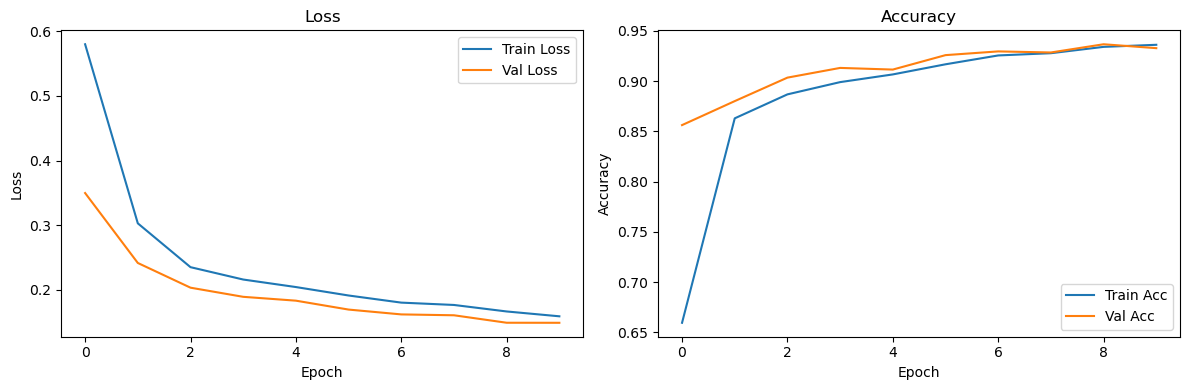

In [17]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Loss')
ax2.plot(history['acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Accuracy')
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        all_preds.extend((out > 0.5).cpu().numpy().astype(int))
        all_labels.extend(y.numpy().astype(int))
print('Confusion Matrix:')
print(confusion_matrix(all_labels, all_preds))
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=['benign', 'malicious']))

Confusion Matrix:
[[6900  243]
 [ 586 4381]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.92      0.97      0.94      7143
   malicious       0.95      0.88      0.91      4967

    accuracy                           0.93     12110
   macro avg       0.93      0.92      0.93     12110
weighted avg       0.93      0.93      0.93     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:**

Not necessarily. Lower loss means the model’s predicted probabilities are closer to the true labels (0 or 1) on average, but it does not always mean higher classification accuracy. For example: (1) **Accuracy is threshold-based**—we use 0.5 to assign classes; the same accuracy can come from different loss values depending on how confident the predictions are. (2) **Class imbalance**—the model can lower loss by being more confident on the majority class while misclassifying the minority class, so accuracy might not improve. (3) **Overfitting**—validation loss can go up while training loss goes down; in that case lower training loss corresponds to worse generalization and possibly lower validation/test accuracy. So we should monitor both loss and accuracy (and validation metrics) to assess performance.



**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**

**Is a large window_size (e.g., 50) good?**  
Not always. A larger window captures more long-range n-gram co-occurrences, which can help if useful patterns span many tokens, but it also (1) **blurs local structure**—short, discriminative patterns (e.g., attack snippets) get mixed with many unrelated n-grams; (2) **increases sparsity and noise**—more pairs have weak or rare co-occurrence counts; (3) **adds computation and memory** for the co-occurrence matrix. For URL classification, malicious cues are often local (e.g., path segments, query patterns), so a moderate window (e.g., 5) is usually a better trade-off than 50.

**Other compression methods:**  
Besides TruncatedSVD we could use: **PCA** (on dense co-occurrence) for linear projection; **GloVe-style** or **word2vec-style** factorizations that fit embeddings to co-occurrence statistics; **autoencoders** (e.g., linear or nonlinear) to compress the co-occurrence or n-gram space; **random projections** for fast, approximate low-rank structure; or **NMF (Non-negative Matrix Factorization)** if we want non-negative embeddings and interpretable factors.


## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`